# Brain Tumor Detection Using a Convolutional Neural Network

**About the Brain MRI Images dataset:**<br>
The dataset contains 2 folders: yes and no which contains 253 Brain MRI Images. The folder yes contains 155 Brain MRI Images that are tumorous and the folder no contains 98 Brain MRI Images that are non-tumorous. You can find it [here](https://www.kaggle.com/navoneel/brain-mri-images-for-brain-tumor-detection).

In [1]:
import tensorflow as tf
import tf_keras
from tensorflow.keras.layers import Conv2D, Input, ZeroPadding2D, BatchNormalization, Activation, MaxPooling2D, Flatten, Dense
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.callbacks import TensorBoard, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score , precision_score
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils import shuffle
from tensorflow.keras.layers import Input, Flatten, Dense, Dropout
from tensorflow.keras.applications import MobileNet ,MobileNetV2 , Xception
from tensorflow.keras.models import Model
from tensorflow.keras import regularizers
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from tensorflow.keras.metrics import Precision , Recall
from tensorflow.keras.optimizers import Adam , Adamax

import keras
import cv2
import imutils
import numpy as np
import matplotlib.pyplot as plt
import time
import seaborn as sns
from sklearn import svm
from os import listdir
from sklearn.svm import LinearSVC
from sklearn.svm import SVC
%matplotlib inline

## Data Preparation & Preprocessing

In order to crop the part that contains only the brain of the image, I used a cropping technique to find the extreme top, bottom, left and right points of the brain. You can read more about it here [Finding extreme points in contours with OpenCV](https://www.pyimagesearch.com/2016/04/11/finding-extreme-points-in-contours-with-opencv/).

In [2]:
def crop_brain_contour(image, plot=False):
    """
    Crop the brain contour from an image by finding the largest external contour.

    Arguments:
        image: Input image (numpy array).
        plot: Boolean, whether to plot the original and cropped image.

    Returns:
        new_image: Cropped image containing the brain region.
    """
    # Convert the image to grayscale and apply Gaussian blur
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (5, 5), 0)

    # Apply binary thresholding
    _, thresh = cv2.threshold(gray, 45, 255, cv2.THRESH_BINARY)
    thresh = cv2.erode(thresh, None, iterations=2)
    thresh = cv2.dilate(thresh, None, iterations=2)

    # Find contours and select the largest one
    cnts = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnts = imutils.grab_contours(cnts)
    c = max(cnts, key=cv2.contourArea)

    # Determine the extreme points of the contour
    extLeft = tuple(c[c[:, :, 0].argmin()][0])
    extRight = tuple(c[c[:, :, 0].argmax()][0])
    extTop = tuple(c[c[:, :, 1].argmin()][0])
    extBot = tuple(c[c[:, :, 1].argmax()][0])

    # Crop the image using the extreme points
    new_image = image[extTop[1]:extBot[1], extLeft[0]:extRight[0]]

    if plot:
        plt.figure(figsize=(10, 5))

        # Plot original image
        plt.subplot(1, 2, 1)
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.title('Original Image')

        # Plot cropped image
        plt.subplot(1, 2, 2)
        plt.imshow(cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.title('Cropped Image')

        plt.tight_layout()
        plt.show()

    return new_image


In order to better understand what it's doing, let's grab an image from the dataset and apply this cropping function to see the result:

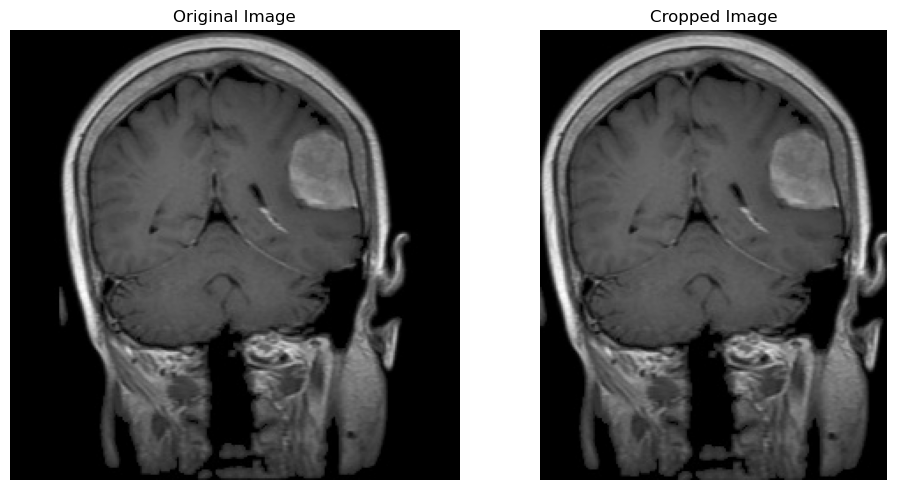

In [3]:
ex_img = cv2.imread('Training/meningioma/M_100.jpg')
ex_new_img = crop_brain_contour(ex_img, True)

### Load up the data:

The following function takes two arguments, the first one is a list of directory paths for the folders 'yes' and 'no' that contain the image data and the second argument is the image size, and for every image in both directories and does the following: 
1. Read the image.
2. Crop the part of the image representing only the brain.
3. Resize the image (because the images in the dataset come in different sizes (meaning width, height and # of channels). So, we want all of our images to be (240, 240, 3) to feed it as an input to the neural network.
4. Apply normalization because we want pixel values to be scaled to the range 0-1.
5. Append the image to <i>X</i> and its label to <i>y</i>.<br>

After that, Shuffle <i>X</i> and <i>y</i>, because the data is ordered (meaning the arrays contains the first part belonging to one class and the second part belonging to the other class, and we don't want that).<br>
Finally, Return <i>X</i> and <i>y</i>.

Load up the data that we augmented earlier in the Data Augmentation notebook.<br>
**Note:** the augmented data directory contains not only the new generated images but also the original images.

In [3]:
def load_data(dir_list, image_size):
    """
    Read images, resize and normalize them in a memory-efficient way.
    Arguments:
        dir_list: list of strings representing file directories.
        image_size: tuple of (image_width, image_height).
    Returns:
        X: A numpy array with shape = (#_examples, image_width, image_height, 3).
        y: A numpy array with shape = (#_examples,).
    """
    X = []
    y = []

    image_width, image_height = image_size

    for directory in dir_list:
        for filename in listdir(directory):
            file_path = f"{directory}/{filename}"
            
            # Load the image
            image = cv2.imread(file_path)
            if image is None:
                continue

            # Resize the image
            image = cv2.resize(image, (image_width, image_height), interpolation=cv2.INTER_CUBIC)

            # Normalize the image
            image = image / 255.0

            # Append the processed image
            X.append(image)

            # Assign labels based on folder name
            folder_name = directory.split('/')[-1].lower()
            if folder_name == 'glioma':
                y.append(0)
            elif folder_name == 'meningioma':
                y.append(1)
            elif folder_name == 'notumor':
                y.append(2)
            elif folder_name == 'pituitary':
                y.append(3)

    # Convert lists to numpy arrays
    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.int32)

    # Shuffle the data
    # X, y = shuffle(X, y, random_state=42)

    print(f'Number of examples: {len(X)}')
    print(f'X shape: {X.shape}')
    print(f'y shape: {y.shape}')

    return X, y


In [2]:
data = np.load("dataset.npz")
X = data["X"]
y = data["y"]


In [3]:
y = y.reshape(-1,1)

In [4]:
X,y = shuffle(X, y , random_state=42)

In [ ]:
training_path = 'Training/'
glioma = training_path + 'glioma' 
meningioma = training_path + 'meningioma'
notumor = training_path + 'notumor'
pituitary = training_path + 'pituitary'
IMG_WIDTH, IMG_HEIGHT = (299, 299)
X, y = load_data([glioma, meningioma , notumor , pituitary], (IMG_WIDTH, IMG_HEIGHT))
np.savez_compressed("dataset_299.npz", X=X, y=y)

In [5]:
def balance_data_downsampling(X_train, y_train):
    unique_classes, counts = np.unique(y_train, return_counts=True)
    min_count = np.min(counts)  # Find the smallest class count

    balanced_X, balanced_y = [], []

    for cls in unique_classes:
        indices = np.where(y_train == cls)[0]
        np.random.shuffle(indices)  
        selected_indices = indices[:min_count] 
        
        balanced_X.append(X_train[selected_indices])
        balanced_y.append(y_train[selected_indices])

    balanced_X = np.concatenate(balanced_X, axis=0)
    balanced_y = np.concatenate(balanced_y, axis=0)

    return balanced_X, balanced_y


In [6]:
balanced_X_train, balanced_y_train = balance_data_downsampling(X, y)
print("Balanced class distribution:", np.unique(balanced_y_train, return_counts=True))

Balanced class distribution: (array([0, 1, 2, 3], dtype=int32), array([2834, 2834, 2834, 2834]))


In [7]:
len(balanced_y_train)

11336

In [22]:
# def augment_data(image, label):
#     image = tf.image.random_flip_left_right(image)
#     image = tf.image.random_brightness(image, 0.1)
#     return image, label

# dataset = tf.data.Dataset.from_tensor_slices((X, y))
# dataset = dataset.map(augment_data).batch(32)

In [37]:
def split_images_and_labels(dataset):
    X_split = []
    y_split = []
    for image, label in dataset:
        X_split.append(image)
        y_split.append(label)
    return tf.concat(X_split, axis=0), tf.concat(y_split, axis=0)

In [38]:
X, y = split_images_and_labels(dataset)

NameError: name 'dataset' is not defined

In [8]:
balanced_X_train= np.array(balanced_X_train)
balanced_y_train = np.array(balanced_y_train)

In [9]:
balanced_y_train.reshape(balanced_y_train.shape[0],-1)

array([[0],
       [0],
       [0],
       ...,
       [3],
       [3],
       [3]], dtype=int32)

In [10]:
balanced_X_train , balanced_y_train = shuffle(balanced_X_train , balanced_y_train , random_state=42)

In [11]:
balanced_y_train = balanced_y_train.reshape(-1,1)

In [12]:
balanced_y_train.shape

(11336, 1)

As we see, we have 2065 images. Each images has a shape of **(240, 240, 3)=(image_width, image_height, number_of_channels)**

In [31]:
def plot_sample_images(X, y, n=50):
    """
    Plots n sample images for both values of y (labels).
    Arguments:
        X: A numpy array with shape = (#_examples, image_width, image_height, #_channels)
        y: A numpy array with shape = (#_examples, 1)
    """

    for label in [1,2,3,4]:
        # grab the first n images with the corresponding y values equal to label
        images = X[np.argwhere(y == label)]
        n_images = images[:n]

        columns_n = 10
        rows_n = int(n/ columns_n)

        plt.figure(figsize=(20, 10))

        i = 1 # current plot
        for image in n_images:
            plt.subplot(rows_n, columns_n, i)
            plt.imshow(image[0])

            plt.tick_params(axis='both', which='both', 
                            top=False, bottom=False, left=False, right=False,
                           labelbottom=False, labeltop=False, labelleft=False, labelright=False)

            i += 1

        label_to_str = lambda label: "glioma" if label == 1 else "meningioma" if label == 2 else "notumor" if label == 3 else "pituitary"
        plt.suptitle(f"Brain Tumor: {label_to_str(label)}")
        plt.show()

### Plot sample images:

In [1]:
#plot_sample_images(X, y)

### Split the data:
Split <i>X</i> and <i>y</i> into training, validation (development) and validation sets.

In [87]:
DATASET_SIZE = 11336
train_size = int(0.9 * DATASET_SIZE)
val_size = int(0.05 * DATASET_SIZE)
test_size = int(0.05 * DATASET_SIZE)

X_train = balanced_X_train[:train_size]
y_train = balanced_y_train[:train_size]
X_val = balanced_X_train[train_size:train_size+val_size]
y_val = balanced_y_train[train_size:train_size+val_size]
X_test = balanced_X_train[train_size+val_size:]
y_test = balanced_y_train[train_size+val_size:]

Let's use the following way to split:<br>
1. 70% of the data for training.
2. 15% of the data for validation.
3. 15% of the data for testing.

In [2]:
np.savez("dataset_90-10.npz", X_train=X_train, y_train=y_train, 
                          X_val=X_val, y_val=y_val, 
                          X_test=X_test, y_test=y_test)

NameError: name 'X_train' is not defined

In [2]:
dataset = np.load('dataset_80-20.npz')
X_train = dataset['X_train']
y_train = dataset['y_train']
X_val = dataset['X_val']
y_val = dataset['y_val']
X_test = dataset['X_test']
y_test = dataset['y_test']

In [3]:
print ("number of training examples = " + str(X_train.shape[0]))
print ("number of development examples = " + str(X_val.shape[0]))
print ("number of test examples = " + str(X_test.shape[0]))
print ("X_train shape: " + str(X_train.shape))
print ("Y_train shape: " + str(y_train.shape))
print ("X_val (dev) shape: " + str(X_val.shape))
print ("Y_val (dev) shape: " + str(y_val.shape))
print ("X_test shape: " + str(X_test.shape))
print ("Y_test shape: " + str(y_test.shape))

number of training examples = 9068
number of development examples = 1133
number of test examples = 1135
X_train shape: (9068, 224, 224, 3)
Y_train shape: (9068, 1)
X_val (dev) shape: (1133, 224, 224, 3)
Y_val (dev) shape: (1133, 1)
X_test shape: (1135, 224, 224, 3)
Y_test shape: (1135, 1)


In [4]:
# Nicely formatted time string
def hms_string(sec_elapsed):
    h = int(sec_elapsed / (60 * 60))
    m = int((sec_elapsed % (60 * 60)) / 60)
    s = sec_elapsed % 60
    return f"{h}:{m}:{round(s,1)}"

In [5]:
def compute_f1_score(y_true, prob):
    # convert the vector of probabilities to a target vector
    y_pred = np.where(prob > 0.5, 1, 0)
    
    score = f1_score(y_true, y_pred)
    
    return score

Define the image shape:

In [6]:
# tensorboard
log_file_name = f'brain_tumor_detection_cnn_{int(time.time())}'
tensorboard = TensorBoard(log_dir=f'logs/{log_file_name}')

In [7]:
# checkpoint
# unique file name that will include the epoch and the validation (development) accuracy
filepath="cnn-parameters-improvement-{epoch:02d}-{val_accuracy:.2f}"
# save the model with the best validation (development) accuracy till now
checkpoint = ModelCheckpoint("models/{}.model.keras".format(filepath, monitor='val_accuracy', verbose=1, save_best_only=True, mode='max'))

## Train the model

In [11]:
input_shape = (299, 299, 3)  # Xception input size

In [12]:
base_model = Xception(include_top = False , weights = "imagenet" , input_shape = input_shape , pooling = "max")
base_model.trainble = False

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 24s 0us/step


In [21]:
model = keras.models.Sequential([
    base_model,
    Flatten(),
    Dropout(rate= 0.3),
    Dense(128, activation= 'relu'),
    Dropout(rate= 0.25),
    Dense(4, activation= 'softmax')
])

model.compile(Adamax(learning_rate= 0.001),
              loss= 'categorical_crossentropy',
              metrics= ['accuracy',
                        Precision(),
                        Recall()])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ xception (Functional)           │ (None, 2048)           │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,124,268 (80.58 MB)

 Trainable params: 21,069,740 (80.37 MB)

 Non-trainable params: 54,528 (213.00 KB)

Let's train for a few more epochs:

In [ ]:
start_time = time.time()

history=model.fit(x=X_train , y=y_train,batch_size = 32 , epochs = 20, validation_data=(X_val , y_val), callbacks=[tensorboard ,checkpoint])
model.save('Xception.keras')
end_time = time.time()
execution_time = (end_time - start_time)
print(f"Elapsed time: {hms_string(execution_time)}")

In [66]:
best_model = keras.models.load_model(filepath='models/cnn-parameters-improvement-20-0.99.model.keras')

In [27]:
start_time = time.time()

best_model.fit(x=X, y=y, batch_size=32, epochs=3, validation_data=(X_val, y_val), callbacks=[tensorboard])

end_time = time.time()
execution_time = (end_time - start_time)
print(f"Elapsed time: {hms_string(execution_time)}")

NameError: name 'best_model' is not defined

In [65]:
start_time = time.time()

best_model.fit(x=X, y=y, batch_size=32, epochs=3, validation_data=(X_val, y_val), callbacks=[tensorboard, checkpoint])

end_time = time.time()
execution_time = (end_time - start_time)
print(f"Elapsed time: {hms_string(execution_time)}")

Epoch 1/3
415/415 ━━━━━━━━━━━━━━━━━━━━ 279s 670ms/step - accuracy: 0.9459 - loss: 0.3101 - val_accuracy: 0.9938 - val_loss: 0.1875
Epoch 2/3
415/415 ━━━━━━━━━━━━━━━━━━━━ 330s 797ms/step - accuracy: 0.9450 - loss: 0.3028 - val_accuracy: 0.9889 - val_loss: 0.2001
Epoch 3/3
415/415 ━━━━━━━━━━━━━━━━━━━━ 313s 754ms/step - accuracy: 0.9388 - loss: 0.3301 - val_accuracy: 0.9931 - val_loss: 0.1918
Elapsed time: 0:15:36.0


In [ ]:
start_time = time.time()

best_model.fit(x=X, y=y, batch_size=32, epochs=3, validation_data=(X_val, y_val), callbacks=[tensorboard, checkpoint])

end_time = time.time()
execution_time = (end_time - start_time)
print(f"Elapsed time: {hms_string(execution_time)}")

Epoch 1/3
275/415 ━━━━━━━━━━━━━━━━━━━━ 2:00 858ms/step - accuracy: 0.9443 - loss: 0.3093

In [ ]:
start_time = time.time()

model.fit(x=X, y=y, batch_size=32, epochs=5, validation_data=(X_val, y_val), callbacks=[tensorboard, checkpoint])

end_time = time.time()
execution_time = (end_time - start_time)
print(f"Elapsed time: {hms_string(execution_time)}")

In [124]:
for key in history.keys():
    print(key)

In [16]:
start_time = time.time()

history = model.fit(x=X_train, y=y_train, batch_size=32, epochs=20, validation_data=(X_val, y_val), callbacks=[tensorboard, checkpoint])

model.save("mob-net_1_model.keras")
end_time = time.time()
execution_time = (end_time - start_time)
print(f"Elapsed time: {hms_string(execution_time)}")

Epoch 1/20
256/256 ━━━━━━━━━━━━━━━━━━━━ 203s 783ms/step - accuracy: 0.7472 - loss: 1.3952 - val_accuracy: 0.9246 - val_loss: 0.2800
Epoch 2/20
256/256 ━━━━━━━━━━━━━━━━━━━━ 185s 724ms/step - accuracy: 0.9365 - loss: 0.2474 - val_accuracy: 0.9523 - val_loss: 0.2177
Epoch 3/20
256/256 ━━━━━━━━━━━━━━━━━━━━ 182s 712ms/step - accuracy: 0.9571 - loss: 0.1949 - val_accuracy: 0.9627 - val_loss: 0.2022
Epoch 4/20
256/256 ━━━━━━━━━━━━━━━━━━━━ 203s 793ms/step - accuracy: 0.9787 - loss: 0.1345 - val_accuracy: 0.9654 - val_loss: 0.1942
Epoch 5/20
256/256 ━━━━━━━━━━━━━━━━━━━━ 176s 690ms/step - accuracy: 0.9817 - loss: 0.1239 - val_accuracy: 0.9730 - val_loss: 0.1843
Epoch 6/20
256/256 ━━━━━━━━━━━━━━━━━━━━ 163s 636ms/step - accuracy: 0.9837 - loss: 0.1207 - val_accuracy: 0.9599 - val_loss: 0.2267
Epoch 7/20
256/256 ━━━━━━━━━━━━━━━━━━━━ 176s 687ms/step - accuracy: 0.9818 - loss: 0.1229 - val_accuracy: 0.9730 - val_loss: 0.1846
Epoch 8/20
256/256 ━━━━━━━━━━━━━━━━━━━━ 167s 652ms/step - accuracy: 0.9833 -

KeyboardInterrupt: 

In [67]:
import pickle
with open('mob-net__2_history.pkl', 'wb') as f:
    pickle.dump(history.history, f)

NameError: name 'history' is not defined

## Plot Loss & Accuracy

In [119]:
def plot_metrics(history):
    
    train_loss = history['loss']
    val_loss = history['val_loss']
    train_acc = history['accuracy']
    val_acc = history['val_accuracy']
    
    # Loss
    plt.figure()
    plt.plot(train_loss, label='Training Loss')
    plt.plot(val_loss, label='Validation Loss')
    plt.title('Loss')
    plt.legend()
    plt.show()
    
    # Accuracy
    plt.figure()
    plt.plot(train_acc, label='Training Accuracy')
    plt.plot(val_acc, label='Validation Accuracy')
    plt.title('Accuracy')
    plt.legend()
    plt.show()

**Note:** Since we trained the model using more than model.fit() function call, this made the history only contain the metric values of the epochs for the last call (which was for 5 epochs), so to plot the metric values across the whole process of trianing the model from the beginning, I had to grab the rest of the values. 

In [122]:
plot_metrics(history) 

KeyError: 'loss'

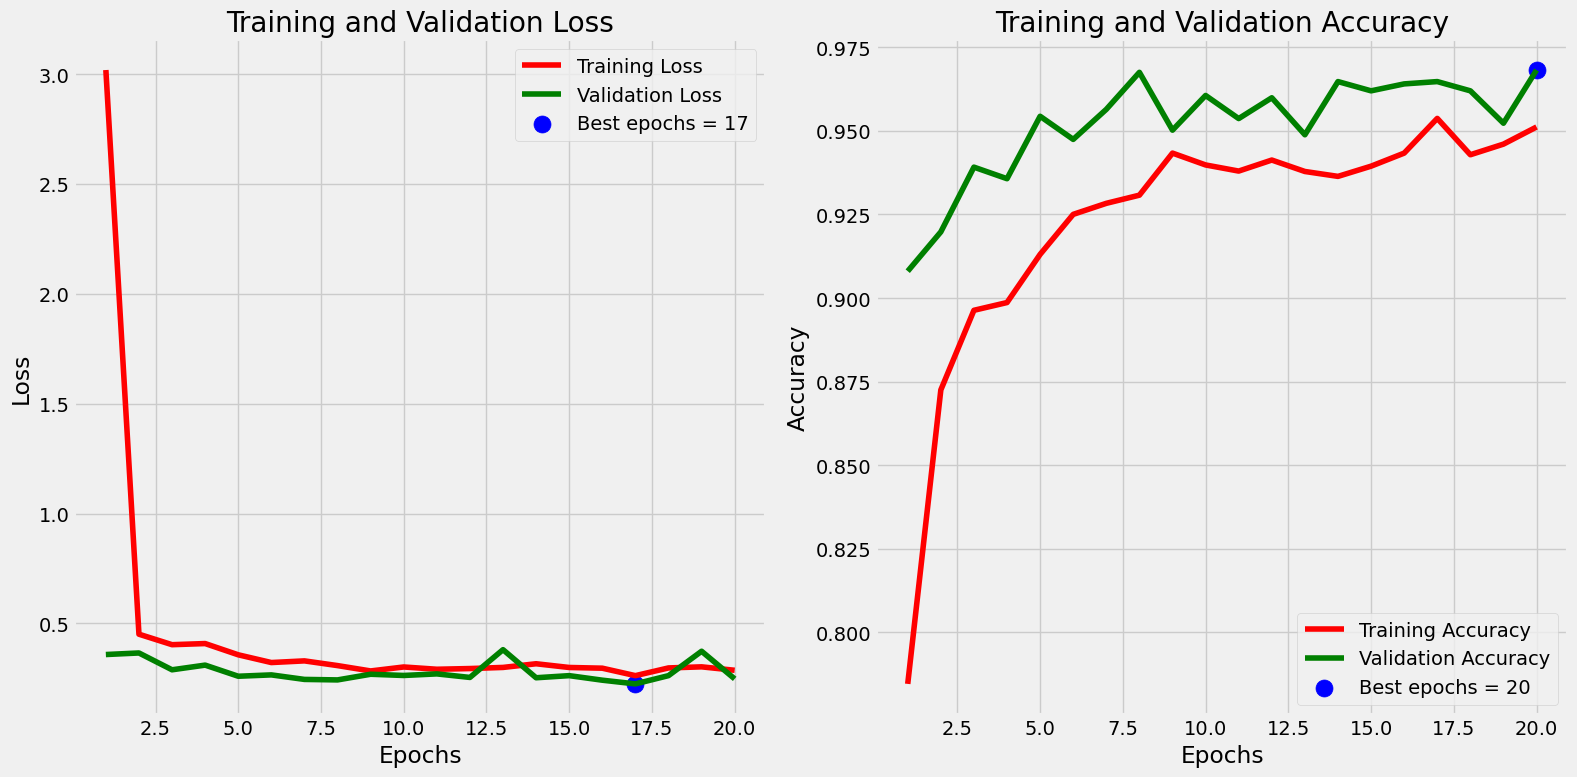

In [85]:
train_acc = history.history['accuracy']
train_loss = history.history['loss']

val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']

index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]

index_acc = np.argmax(val_acc)
val_highest = val_acc[index_acc]

Epochs = [i+1 for i in range(len(train_acc))]

loss_label = f'Best epochs = {str(index_loss +1)}'
acc_label = f'Best epochs = {str(index_acc + 1)}'

# Training history
plt.figure(figsize=(16,8))
plt.style.use('fivethirtyeight')

plt.subplot(1,2,1)
plt.plot(Epochs , train_loss , 'r' , label = 'Training Loss')
plt.plot(Epochs , val_loss , 'g' , label = 'Validation Loss')
plt.scatter(index_loss + 1 , val_lowest , s = 150 , c = 'blue' , label = loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(Epochs , train_acc , 'r' , label = 'Training Accuracy')
plt.plot(Epochs , val_acc , 'g' , label = 'Validation Accuracy')
plt.scatter(index_acc + 1 , val_highest , s = 150 , c = 'blue' , label = acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.savefig('visulize_fr_MLP')
plt.legend()
plt.savefig('Brain_tumor_mob_net')
plt.tight_layout()
plt.show()

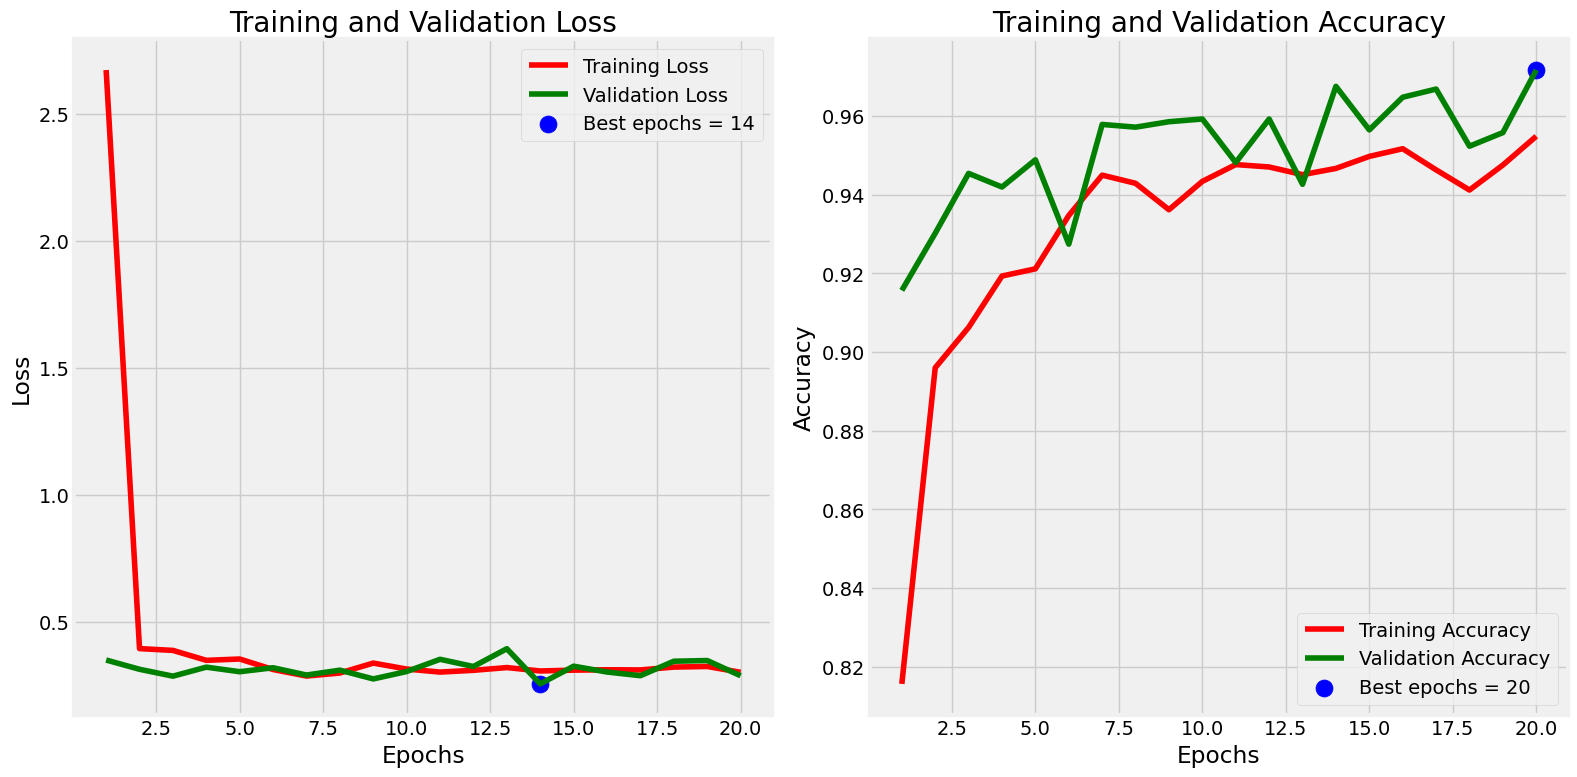

In [63]:
train_acc = history.history['accuracy']
train_loss = history.history['loss']

val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']

index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]

index_acc = np.argmax(val_acc)
val_highest = val_acc[index_acc]

Epochs = [i+1 for i in range(len(train_acc))]

loss_label = f'Best epochs = {str(index_loss +1)}'
acc_label = f'Best epochs = {str(index_acc + 1)}'

# Training history
plt.figure(figsize=(16,8))
plt.style.use('fivethirtyeight')

plt.subplot(1,2,1)
plt.plot(Epochs , train_loss , 'r' , label = 'Training Loss')
plt.plot(Epochs , val_loss , 'g' , label = 'Validation Loss')
plt.scatter(index_loss + 1 , val_lowest , s = 150 , c = 'blue' , label = loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(Epochs , train_acc , 'r' , label = 'Training Accuracy')
plt.plot(Epochs , val_acc , 'g' , label = 'Validation Accuracy')
plt.scatter(index_acc + 1 , val_highest , s = 150 , c = 'blue' , label = acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.savefig('visulize_fr_MLP')
plt.legend()
plt.savefig('Brain_tumor_mob_net')
plt.tight_layout()
plt.show()

# Results

Let's experiment with the best model (the one with the best validation accuracy):

Concretely, the model at the 23rd iteration with validation accuracy of 91%

### Load the best model

In [47]:
best_model = keras.models.load_model(filepath='models/cnn-parameters-improvement-04-0.99.model.keras')

In [48]:
best_model.metrics_names

['loss', 'compile_metrics']

Evaluate the best model on the testing data:

In [49]:
loss, acc = best_model.evaluate(x=X_test, y=y_test)

18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 208ms/step - accuracy: 0.9800 - loss: 0.1103


### Accuracy of the best model on the testing data:

In [50]:
print (f"Test Loss = {loss}")
print (f"Test Accuracy = {acc}")

Test Loss = 0.11148292571306229
Test Accuracy = 0.9823943376541138


### F1 score for the best model on the testing data:

In [51]:
y_test_prob = best_model.predict(X_test)

/opt/anaconda3/lib/python3.12/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_3']
Received: inputs=Tensor(shape=(32, 224, 224, 3))
  warnings.warn(msg)
/opt/anaconda3/lib/python3.12/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_2']
Received: inputs=Tensor(shape=(32, 224, 224, 3))
  warnings.warn(msg)


18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 222ms/step


In [52]:
y_pred = np.argmax(y_test_prob , axis=1)

In [53]:
f1score = f1_score(y_test, np.argmax(y_test_prob , axis=1), average='micro')
predicted_labels=np.argmax(y_test_prob , axis = 1)
print(f"F1 score: {f1score}")

F1 score: 0.9823943661971831


In [54]:
from sklearn.metrics import precision_score, recall_score, f1_score

In [55]:
precision=precision_score(y_test, y_pred, average='macro')  # For multi-class
recall = recall_score(y_test, y_pred , average='macro')

In [56]:
precision

0.9825064599483204

In [57]:
recall

0.9823394143448422

In [58]:
predicted_labels=np.argmax(y_test_prob , axis=1)

Let's also find the f1 score on the validation data:

In [84]:
predicted_labels=np.argmax(y_test_prob , axis=1)

In [85]:
cm = confusion_matrix(y_test, predicted_labels)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[395  25   1   2]
 [ 11 418   0  15]
 [  0   1 416   0]
 [  0   3   0 414]]


In [86]:
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.97      0.93      0.95       423
           1       0.94      0.94      0.94       444
           2       1.00      1.00      1.00       417
           3       0.96      0.99      0.98       417

    accuracy                           0.97      1701
   macro avg       0.97      0.97      0.97      1701
weighted avg       0.97      0.97      0.97      1701



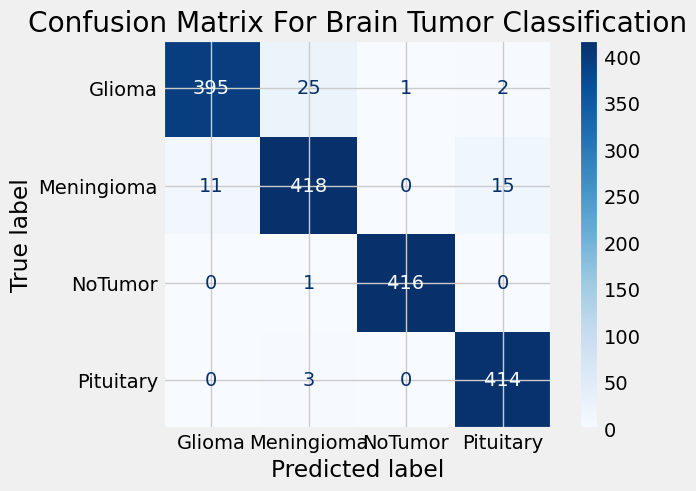

In [87]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Glioma', 'Meningioma', 'NoTumor', 'Pituitary'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix For Brain Tumor Classification")
plt.show()

In [88]:
predicted_labels


array([0, 1, 2, ..., 3, 1, 0])

NameError: name 'labels' is not defined

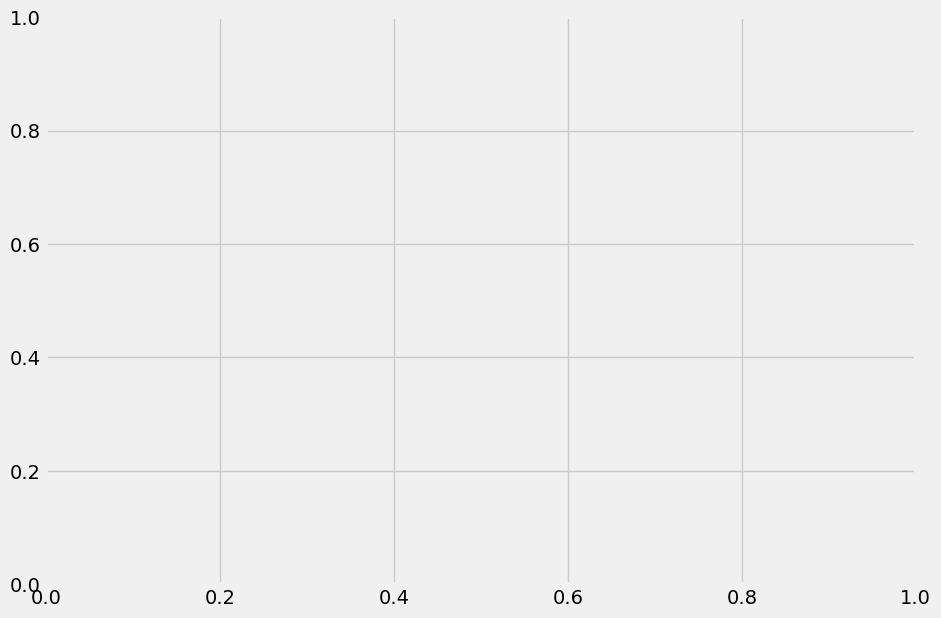

In [89]:
cm = confusion_matrix(y_test,predicted_labels)

# Display the confusion matrix
fig, ax = plt.subplots(figsize=(10, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', ax=ax)

# Add title and labels
ax.set_title('Confusion Matrix For Brain Tumor Classification')
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')

# Save the figure
plt.savefig('confusion_matrix_brain_tumor.png')

# Show the plot
plt.show()

### Results Interpretation

Let's remember the percentage of positive and negative examples:

As expectred, the percentage of positive examples are around 50%.

# Conclusion:

#### Now, the model detects brain tumor with:<br>
**88.7%** accuracy on the **test set**.<br>
**0.88** f1 score on the **test set**.<br>
These resutls are very good considering that the data is balanced.

**Performance Table:**

| <!-- -->  | Validation set | Test set |
| --------- | -------------- | -------- |
| Accuracy  | 91%            | 89%      |
| F1 score  | 0.91           | 0.88     |

Hooray!